# Pipeline demo: detection, tracking, and pitch calibration

*Using Projective Transformation for the Spatial Analysis of Team Behaviors in Football*

This notebook exercises the core of the system built for the thesis:

1. Clone the `pitchvision` package and install its dependencies.
2. Mount Google Drive and locate footage in the `BuildingAction` / `Goals` / `SetPieces` folders.
3. Sanity-check YOLOv8 detection (players + ball) on a single frame.
4. Calibrate the pitch homography automatically from detected pitch keypoints (with a manual fallback).
5. Cluster players into two teams by jersey colour.
6. Run the full detection + ByteTrack tracking + homography pipeline over a clip, with team labels attached.
7. Save the resulting per-frame pitch-coordinate tracks to Drive for the phase-specific analyses (goal-scoring opportunity, build-up, set pieces) built in later notebooks.

## 1. Clone the repository and install dependencies

**If you've already run this notebook earlier in the current Colab session** and are re-pulling newer code: Python caches `pitchvision` in memory after the first `import`, so a `git pull` alone won't pick up new/changed symbols (e.g. a new class) in already-running cells. After pulling, use **Runtime > Restart session**, then **Run all** - the commit hash printed below should match the latest commit on GitHub.

In [18]:
import os
import sys

REPO_URL = "https://github.com/Batomet/Magisterka.git"
BRANCH = "claude/football-spatial-analysis-thesis-lx13x7"
REPO_DIR = "/content/Magisterka"

if not os.path.isdir(REPO_DIR):
    !git clone --branch {BRANCH} {REPO_URL} {REPO_DIR}
%cd {REPO_DIR}
!git pull
!git log -1 --oneline

# Put the package on sys.path directly, rather than relying on `pip install -e .`
# to register it - editable installs use a .pth/import-finder file that Python's
# site module only processes at interpreter startup, so one run mid-session (in
# an already-running Colab kernel) doesn't reliably become importable.
SRC_DIR = os.path.join(REPO_DIR, "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

/content/Magisterka
Already up to date.


In [19]:
!pip install -q -r requirements.txt

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for pitchvision (pyproject.toml) ... done


## 2. Mount Google Drive and locate footage

In [20]:
from pitchvision import DriveConfig, mount_drive

mount_drive()

# Adjust `root` if BuildingAction/Goals/SetPieces don't live directly under My Drive.
drive_cfg = DriveConfig(root="/content/drive/MyDrive/Magisterka")
print(drive_cfg.building_action_path)
print(drive_cfg.goals_path)
print(drive_cfg.set_pieces_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Magisterka/BuildingAction
/content/drive/MyDrive/Magisterka/Goals
/content/drive/MyDrive/Magisterka/SetPieces


In [21]:
from pitchvision import list_videos

goal_videos = list_videos(drive_cfg.goals_path)
print(f"Found {len(goal_videos)} videos in Goals/")

sample_video = goal_videos[0]
sample_video

Found 6 videos in Goals/


'/content/drive/MyDrive/Magisterka/Goals/Goals00017249.mp4'

## 3. Detection sanity check

Runs a COCO-pretrained YOLOv8 model on the first frame, restricted to the `person` (players/referees) and `sports ball` classes.

13 detections in frame 0


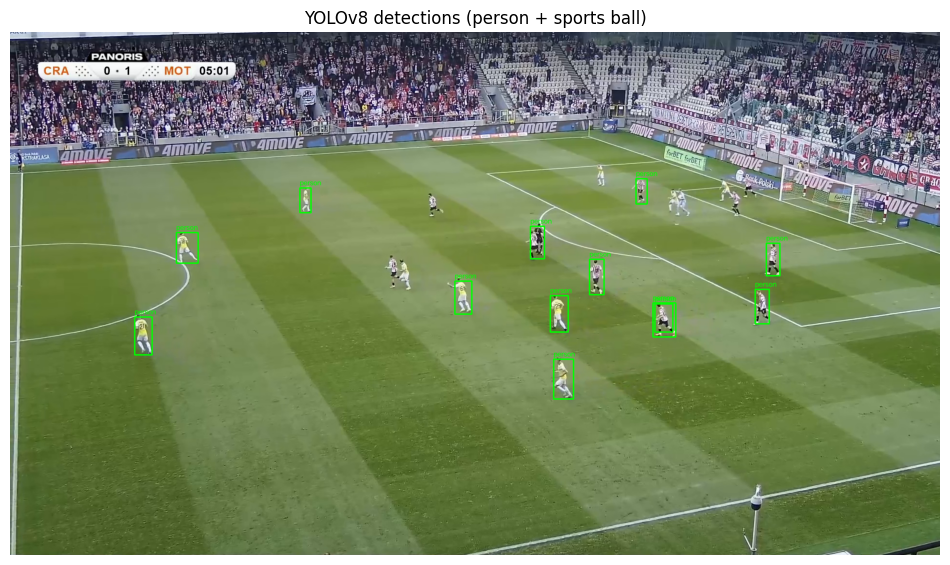

In [22]:
import cv2
import matplotlib.pyplot as plt

from pitchvision import PlayerBallDetector, VideoFrames

frames = VideoFrames(sample_video)
first_frame = frames.read_frame(0)

detector = PlayerBallDetector(weights="yolov8n.pt", confidence=0.3, imgsz=1280)
detections = detector.detect(first_frame)
print(f"{len(detections)} detections in frame 0")

vis = first_frame.copy()
for det in detections:
    x1, y1, x2, y2 = det.xyxy.astype(int)
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(vis, det.class_name, (x1, max(y1 - 5, 0)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLOv8 detections (person + sports ball)")
plt.show()

## 4. Pitch calibration

Two options, in order of preference:

**4A. Automatic (default).** A pretrained YOLOv8-pose model ([`football-pitch-detection.pt`](https://github.com/roboflow/sports), trained to localise 32 standard pitch keypoints - corners, box corners, centre-circle tangents, ...) detects the keypoints directly in the frame; the confidently-detected ones are matched against their known metric positions and fed straight into `PitchCalibrator.from_point_pairs`. No manual clicking, and it works per-frame so it can also handle camera pans/cuts if you re-run it per shot.

**4B. Manual fallback.** If 4A can't find enough confident keypoints for a given clip (heavy occlusion, an unusual crop, unusual lighting), fall back to reading pixel coordinates off the frame by hand.

In [23]:
from pitchvision import PitchKeypointDetector, download_pitch_keypoint_weights

# Cached on Drive so you don't re-download this every Colab session.
weights_path = download_pitch_keypoint_weights(
    "/content/drive/MyDrive/pitchvision_models/football-pitch-detection.pt"
)

keypoint_detector = PitchKeypointDetector(weights=weights_path, confidence=0.5)
calibrator = keypoint_detector.calibrate(first_frame)

xy, conf = keypoint_detector.detect(first_frame)
confident = conf >= keypoint_detector.confidence
print(f"{confident.sum()}/32 pitch keypoints detected with confidence >= {keypoint_detector.confidence}")

Downloading...
From (original): https://drive.google.com/uc?id=1Ma5Kt86tgpdjCTKfum79YMgNnSjcoOyf
From (redirected): https://drive.google.com/uc?id=1Ma5Kt86tgpdjCTKfum79YMgNnSjcoOyf&confirm=t&uuid=6d15dac3-ace0-4fc4-86c3-4cd894463209
To: /content/drive/MyDrive/pitchvision_models/football-pitch-detection.pt
100%|██████████| 140M/140M [00:03<00:00, 37.6MB/s]


13/32 pitch keypoints detected with confidence >= 0.5


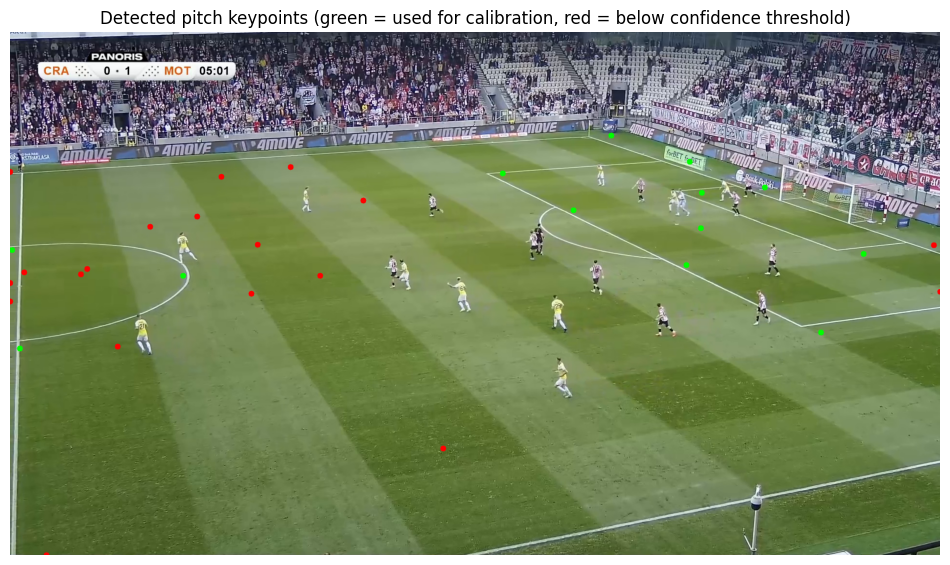

In [24]:
vis = first_frame.copy()
for (x, y), c, is_confident in zip(xy, conf, confident):
    color = (0, 255, 0) if is_confident else (0, 0, 255)
    cv2.circle(vis, (int(x), int(y)), 6, color, -1)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Detected pitch keypoints (green = used for calibration, red = below confidence threshold)")
plt.show()

### 4B. Manual fallback (safe to leave as-is if 4A worked)

This cell is a no-op by default (`USE_MANUAL_FALLBACK = False`), so it's safe to run every time, including with Run All. Only set that flag to True if `keypoint_detector` above couldn't find enough confident keypoints for this clip - then hover over the image below to read exact pixel coordinates and fill in `landmark_pixels`.

In [25]:
import plotly.express as px

from pitchvision import PITCH_LANDMARKS_M

fig = px.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
fig.update_layout(title="Hover to read pixel coordinates for the landmarks below", height=700)
fig.show()

print("Available landmark names:", list(PITCH_LANDMARKS_M.keys()))

Available landmark names: ['top_left_corner', 'bottom_left_corner', 'top_right_corner', 'bottom_right_corner', 'centre_top', 'centre_bottom', 'centre_spot', 'left_penalty_top', 'left_penalty_bottom', 'right_penalty_top', 'right_penalty_bottom', 'left_penalty_spot', 'right_penalty_spot', 'left_six_yard_top', 'left_six_yard_bottom', 'right_six_yard_top', 'right_six_yard_bottom', 'left_goal_post_top', 'left_goal_post_bottom', 'right_goal_post_top', 'right_goal_post_bottom', 'centre_circle_top', 'centre_circle_bottom', 'centre_circle_left', 'centre_circle_right']


In [ ]:
import numpy as np

from pitchvision import PitchCalibrator

# Set this to True only if 4A (automatic) couldn't find enough confident
# keypoints for this clip. With this False (the default), this cell is a
# no-op, so it's safe to leave in place when running the whole notebook
# with Run All.
USE_MANUAL_FALLBACK = False

if not USE_MANUAL_FALLBACK:
    print("Skipping manual fallback (USE_MANUAL_FALLBACK is False). "
          "Using the calibrator from 4A.")
else:
    # EDIT THIS: replace every value with the pixel (x, y) you read off the
    # hover tooltip above for that landmark, for THIS frame. Do not leave
    # these defaults - they are placeholders and do not correspond to real
    # points in your video.
    landmark_pixels = {
        "left_penalty_top": (123, 456),
        "left_penalty_bottom": (110, 620),
        "left_six_yard_top": (250, 430),
        "centre_spot": (900, 300),
    }

    _PLACEHOLDER = {
        "left_penalty_top": (123, 456),
        "left_penalty_bottom": (110, 620),
        "left_six_yard_top": (250, 430),
        "centre_spot": (900, 300),
    }
    assert landmark_pixels != _PLACEHOLDER, (
        "landmark_pixels still holds the placeholder values - edit them with real "
        "pixel coordinates read off the hover tooltip in the cell above before continuing."
    )

    pixel_points = np.array(list(landmark_pixels.values()))
    pitch_points = np.array([PITCH_LANDMARKS_M[name] for name in landmark_pixels])

    manual_calibrator = PitchCalibrator.from_point_pairs(pixel_points, pitch_points)
    error_m = manual_calibrator.reprojection_error(pixel_points, pitch_points)
    print("Mean reprojection error (m):", error_m)
    if error_m > 2.0:
        print(
            "WARNING: reprojection error is high (>2m). Double-check that each pixel "
            "coordinate actually matches its landmark name and that all points come "
            "from this frame - a single mismatched pair can produce a garbage homography."
        )

    # Actually use this fallback calibration for the rest of the notebook:
    calibrator = manual_calibrator

### Sanity-check the calibration

Project the frame's detected players onto the top-down pitch view; they should land inside the pitch outline in positions that roughly match the original frame.

In [ ]:
from pitchvision import PITCH_LENGTH_M, PITCH_WIDTH_M, draw_pitch, plot_positions

foot_points = np.array([d.foot_point for d in detections if d.class_name == "person"])
pitch_positions = calibrator.pixel_to_pitch(foot_points)

margin = 10.0  # metres of slack around the pitch outline
in_bounds = (
    (pitch_positions[:, 0] >= -margin) & (pitch_positions[:, 0] <= PITCH_LENGTH_M + margin) &
    (pitch_positions[:, 1] >= -margin) & (pitch_positions[:, 1] <= PITCH_WIDTH_M + margin)
)
if in_bounds.mean() < 0.8:
    print(
        f"WARNING: only {in_bounds.sum()}/{len(in_bounds)} projected players land "
        "near the pitch. The calibration is likely wrong - revisit cell 4A/4B above."
    )

ax = draw_pitch()
plot_positions(ax, pitch_positions, color="yellow", s=40, edgecolors="black")
plt.title("Detected players projected onto the pitch (frame 0)")
plt.show()

## 5. Team classification

Cluster player detections into two groups by jersey colour (`pitchvision.team`), so downstream analyses can compare each team's shape/space separately. This uses the specialized `football-player-detection.pt` checkpoint (also from [roboflow/sports](https://github.com/roboflow/sports); a 4-class model: ball, goalkeeper, player, referee) instead of the generic COCO model, so referees are excluded from the colour clustering outright and goalkeepers get resolved by pitch position afterwards - both would otherwise pollute a 2-cluster jersey-colour fit. The clustering itself is still a classical colour approach (median hue/saturation of the torso crop + KMeans), lightweight enough to run here with no extra model beyond this one download. It is *not* team-identity aware - cluster `0`/`1` are arbitrary until you check `cluster_swatches` below.

In [ ]:
import numpy as np

from pitchvision import (
    PlayerBallDetector,
    SPORTS_DETECTION_CLASSES,
    TeamClassifier,
    collect_jersey_samples,
    download_player_detection_weights,
)

player_weights_path = download_player_detection_weights(
    "/content/drive/MyDrive/pitchvision_models/football-player-detection.pt"
)
player_detector = PlayerBallDetector(
    weights=player_weights_path, confidence=0.3, classes=SPORTS_DETECTION_CLASSES, imgsz=1280
)

jersey_samples = collect_jersey_samples(sample_video, player_detector, class_names=("player",), stride=30)
print(f"Collected {len(jersey_samples)} jersey colour samples")

team_classifier = TeamClassifier(n_clusters=2)
team_classifier.fit(np.array([s.color for s in jersey_samples]))
team_classifier.cluster_swatches

**Audit the fit before trusting it.** Cluster sizes and swatch colours alone can't tell you whether the split is real jersey-colour signal or an artefact (grass bleed-through into a loose crop, shadow/lighting, motion blur). The scatter below shows every sampled point in (hue, saturation) space, coloured by assigned cluster; the crop grid shows what those points actually look like. Two visually separated blobs of roughly similar size = trustworthy. One tight blob plus a handful of scattered outliers = the clustering isn't finding team identity - it's finding whatever few samples looked different by chance.

In [ ]:
from pitchvision import plot_jersey_color_samples

cluster_labels = team_classifier.predict_from_colors(np.array([s.color for s in jersey_samples]))
plot_jersey_color_samples(jersey_samples, cluster_labels, cluster_colors={0: "yellow", 1: "red"})

In [ ]:
swatches = team_classifier.cluster_swatches
fig, axes = plt.subplots(1, len(swatches), figsize=(4 * len(swatches), 2))
for team_id, (ax, rgb) in enumerate(zip(axes, swatches)):
    ax.imshow([[rgb]])
    ax.set_title(f"team_id = {team_id}")
    ax.axis("off")
plt.show()

## 6. Full pipeline: detection + ByteTrack tracking + homography

`max_frames` caps the run while iterating on calibration; set it to `None` for the full clip.

In [ ]:
from pitchvision import PlayerTracker, TrackingPipeline

tracker = PlayerTracker(
    weights=player_weights_path, confidence=0.3, classes=SPORTS_DETECTION_CLASSES, imgsz=1280
)
pipeline = TrackingPipeline(
    tracker=tracker,
    calibrator=calibrator,
    team_classifier=team_classifier,
    team_eligible_class_names=("player",),
)

tracks_df = pipeline.run(sample_video, max_frames=250)
tracks_df["class_name"].value_counts()

In [ ]:
TEAM_COLORS = {0: "yellow", 1: "red"}
TRAJECTORY_CLASSES = ("player", "goalkeeper")  # referees excluded from team-level analysis

ax = draw_pitch()
for track_id, group in tracks_df[tracks_df["class_name"].isin(TRAJECTORY_CLASSES)].groupby("track_id"):
    team_id = group["team_id"].iloc[0]
    color = TEAM_COLORS.get(team_id, "gray")
    ax.plot(group["pitch_x"], group["pitch_y"], linewidth=1, alpha=0.7, color=color)
plt.title("Player trajectories over the sampled frames (colour = team)")
plt.show()

## 7. Save tracks for downstream analysis

In [ ]:
output_dir = "/content/drive/MyDrive/pitchvision_outputs"
os.makedirs(output_dir, exist_ok=True)

out_path = os.path.join(output_dir, os.path.splitext(os.path.basename(sample_video))[0] + "_tracks.csv")
tracks_df.to_csv(out_path, index=False)
out_path

## Next steps

This notebook covers the shared foundation only. Not yet implemented, planned for later notebooks:

- **Goal-scoring opportunity phase**: defensive compactness (inter-player distances) and space control (Voronoi diagrams).
- **Build-up phase**: Effective Playing Space via Convex Hull, and stretch/compactness via formation centroids.
- **Set pieces / breaks in play**: repeatability of positional structures, and static-to-dynamic transition timing after the restart.